# Stock Market Sector Analysis & Movement Predictor
### ML Mini Project — Department of Computer Science & Engineering
**Algorithms:** K-Means Clustering + Decision Tree + Random Forest  
**Dataset:** S&P 500 Five-Year Stock Data (Kaggle)  
**Target:** Predict next-day stock price movement — Up (1) or Down (0)

by Atharv Shivankar




## Phase 1 — Import Libraries

In [5]:
# ── Standard Libraries ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Scikit-learn: Preprocessing ──
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ── Scikit-learn: Clustering ──
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ── Scikit-learn: Classification ──
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier

# ── Scikit-learn: Evaluation ──
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay, roc_curve, auc)

# ── Plot Style ──
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ All libraries imported successfully.")
print(f"   pandas  : {pd.__version__}")
print(f"   numpy   : {np.__version__}")
import sklearn; print(f"   sklearn : {sklearn.__version__}")


✅ All libraries imported successfully.
   pandas  : 3.0.2
   numpy   : 2.4.4
   sklearn : 1.8.0


## Phase 2 — Load & Inspect the Dataset
**Dataset:** S&P 500 Five-Year Stock Data  
**Source:** https://www.kaggle.com/datasets/camnugent/sandp500  
**File needed:** `all_stocks_5yr.csv`

**Columns:**
| Column | Description |
|--------|-------------|
| `date` | Trading date |
| `open` | Opening price (USD) |
| `high` | Daily high price (USD) |
| `low` | Daily low price (USD) |
| `close` | Closing price (USD) |
| `volume` | Shares traded |
| `Name` | Stock ticker symbol |


In [10]:
# ── Load CSV ──
df = pd.read_csv('all_stocks_5yr.csv', parse_dates=['date'])

print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"  Shape          : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  Date range     : {df['date'].min().date()}  →  {df['date'].max().date()}")
print(f"  Unique stocks  : {df['Name'].nunique()}")
print(f"  Trading days   : ~{df.groupby('Name').size().mean():.0f} per stock")
print()
df.head(10)


DATASET OVERVIEW
  Shape          : 619,040 rows × 7 columns
  Date range     : 2013-02-08  →  2018-02-07
  Unique stocks  : 505
  Trading days   : ~1226 per stock



,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL
5,2013-02-15,13.93,14.61,13.93,14.50,15628000,AAL
6,2013-02-19,14.33,14.56,14.08,14.26,11354400,AAL
7,2013-02-20,14.17,14.26,13.15,13.33,14725200,AAL
8,2013-02-21,13.62,13.95,12.90,13.37,11922100,AAL
9,2013-02-22,13.57,13.60,13.21,13.57,6071400,AAL


In [11]:
# ── Data types and null check ──
print("=== DATA TYPES ===")
print(df.dtypes)
print()
print("=== MISSING VALUES ===")
nulls = df.isnull().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else "✅ No missing values found!")


=== DATA TYPES ===
date      datetime64[us]
open             float64
high             float64
low              float64
close            float64
volume             int64
Name                 str
dtype: object

=== MISSING VALUES ===
open    11
high     8
low      8
dtype: int64


In [12]:
# ── Descriptive Statistics ──
print("=== DESCRIPTIVE STATISTICS ===")
df[['open','high','low','close','volume']].describe().round(2)


=== DESCRIPTIVE STATISTICS ===


,open,high,low,close,volume
count,619029.00,619032.00,619032.00,619040.00,6.190400e+05
mean,83.02,83.78,82.26,83.04,4.321823e+06
std,97.38,98.21,96.51,97.39,8.693610e+06
min,1.62,1.69,1.50,1.59,0.000000e+00
25%,40.22,40.62,39.83,40.24,1.070320e+06
50%,62.59,63.15,62.02,62.62,2.082094e+06
75%,94.37,95.18,93.54,94.41,4.284509e+06
max,2044.00,2067.99,2035.11,2049.00,6.182376e+08


## Phase 3 — Exploratory Data Analysis (EDA)
EDA helps us understand the distribution, trends, and relationships in the data before modelling.


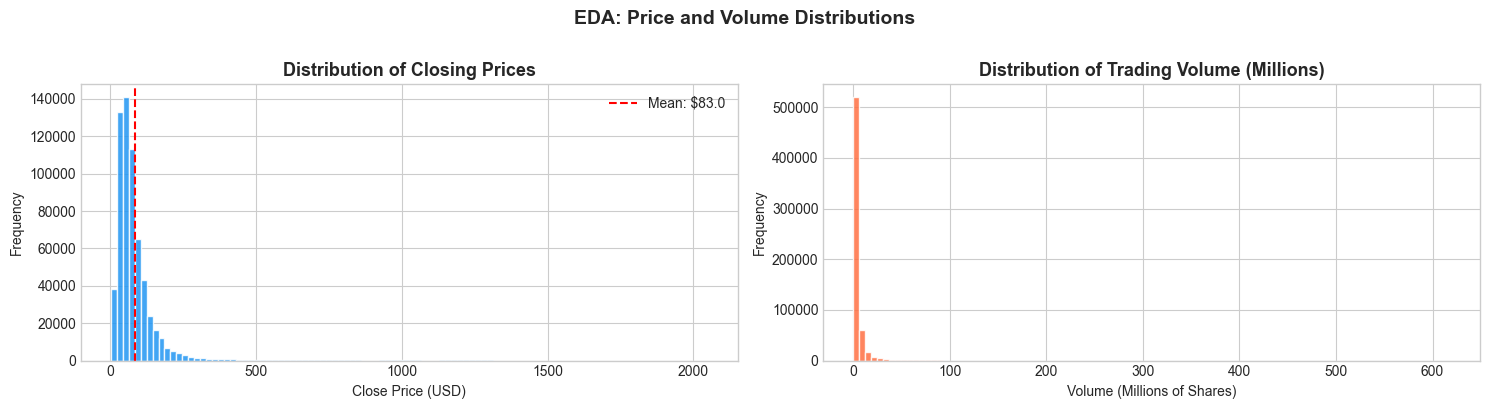

✅ Saved: eda_01_distributions.png


In [13]:
# ── 3.1 Distribution of Close Price and Volume ──
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].hist(df['close'], bins=100, color='#2196F3', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of Closing Prices', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Close Price (USD)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['close'].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: ${df["close"].mean():.1f}')
axes[0].legend()

axes[1].hist(df['volume'] / 1e6, bins=100, color='#FF7043', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribution of Trading Volume (Millions)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Volume (Millions of Shares)')
axes[1].set_ylabel('Frequency')

plt.suptitle('EDA: Price and Volume Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_01_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_01_distributions.png")


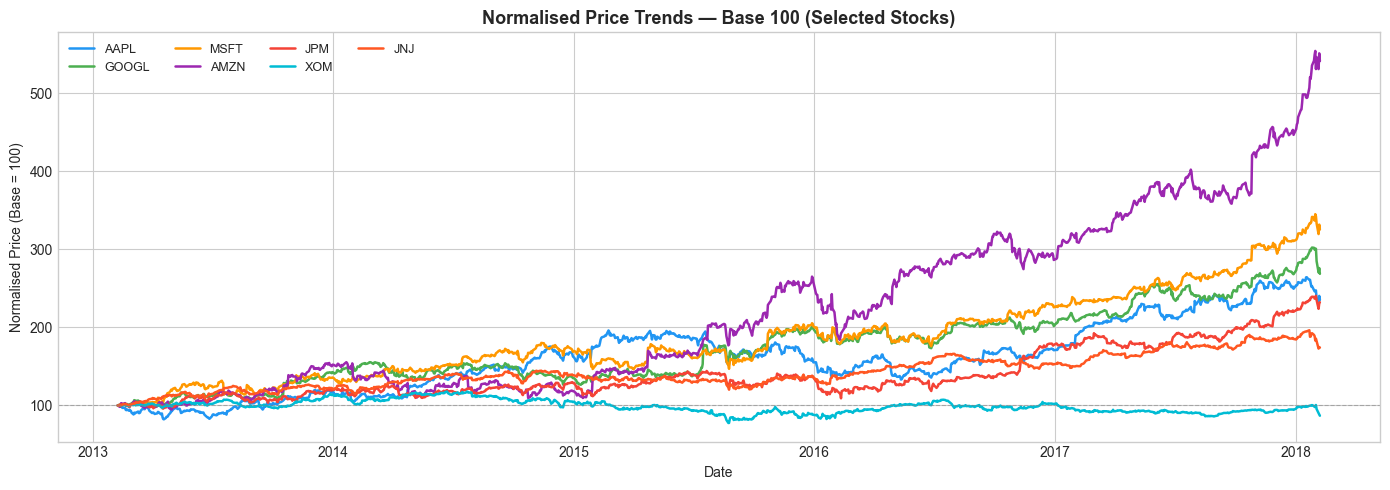

In [14]:
# ── 3.2 Normalised Price Trends (selected stocks) ──
SAMPLE_STOCKS = ['AAPL', 'GOOGL', 'MSFT', 'AMZN', 'JPM', 'XOM', 'JNJ']
AVAILABLE     = [s for s in SAMPLE_STOCKS if s in df['Name'].values]
COLORS        = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336','#00BCD4','#FF5722']

fig, ax = plt.subplots(figsize=(14, 5))
for i, stock in enumerate(AVAILABLE):
    subset = df[df['Name'] == stock].sort_values('date').set_index('date')
    normalised = (subset['close'] / subset['close'].iloc[0]) * 100
    ax.plot(normalised, label=stock, color=COLORS[i % len(COLORS)], linewidth=1.8)

ax.set_title('Normalised Price Trends — Base 100 (Selected Stocks)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Normalised Price (Base = 100)')
ax.legend(ncol=4, fontsize=9)
ax.axhline(100, linestyle='--', color='grey', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.savefig('eda_02_price_trends.png', dpi=150, bbox_inches='tight')
plt.show()


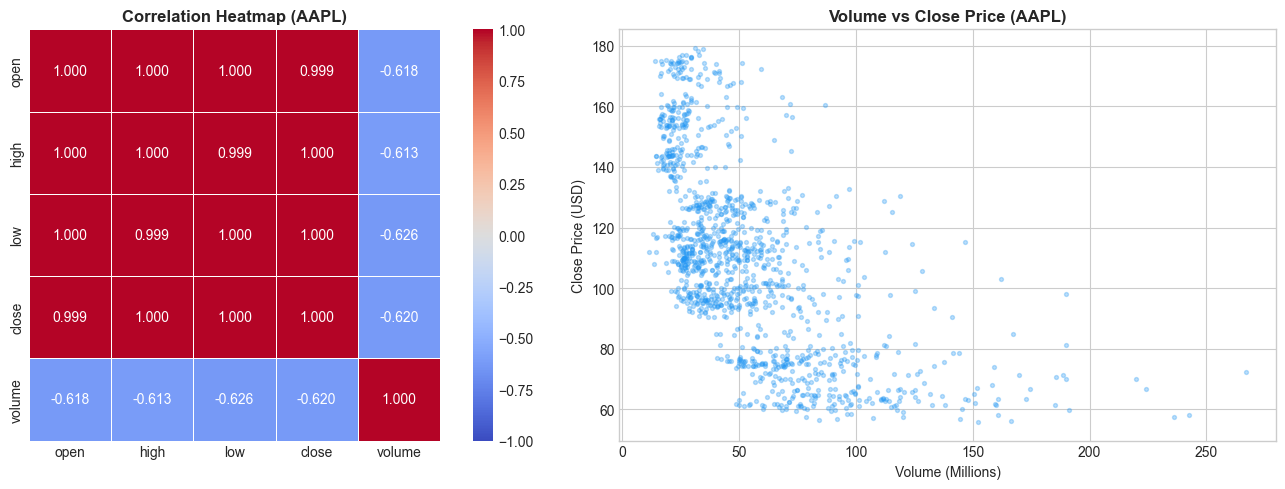

In [15]:
# ── 3.3 Correlation Heatmap (AAPL) ──
aapl = df[df['Name'] == 'AAPL'][['open','high','low','close','volume']].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
sns.heatmap(aapl.corr(), annot=True, fmt='.3f', cmap='coolwarm',
            square=True, linewidths=0.5, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Correlation Heatmap (AAPL)', fontsize=12, fontweight='bold')

# Volume vs Close scatter
axes[1].scatter(aapl['volume']/1e6, aapl['close'], alpha=0.3, s=8, color='#2196F3')
axes[1].set_xlabel('Volume (Millions)')
axes[1].set_ylabel('Close Price (USD)')
axes[1].set_title('Volume vs Close Price (AAPL)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_03_correlation.png', dpi=150, bbox_inches='tight')
plt.show()


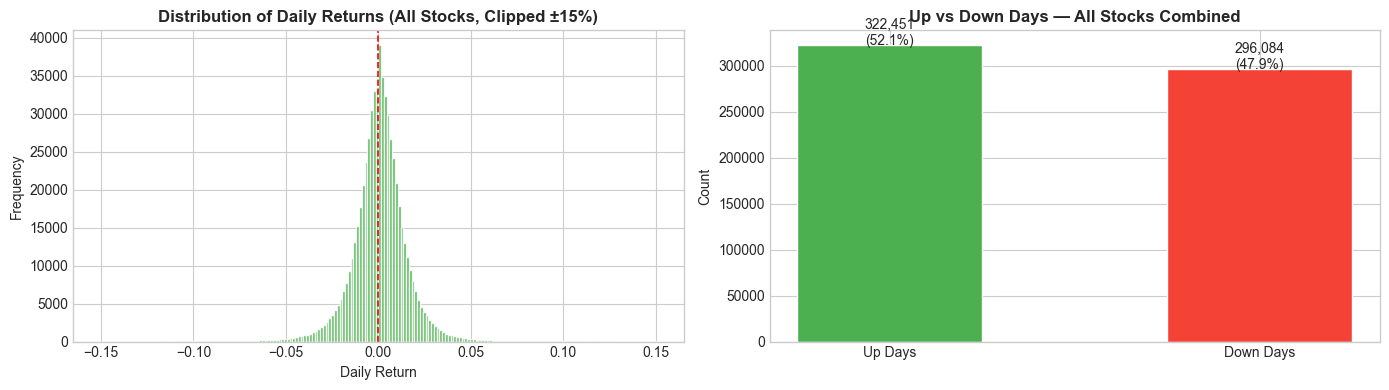


Overall Up days  : 322,451  (52.13%)
Overall Down days: 296,084  (47.87%)


In [16]:
# ── 3.4 Market-wide daily returns distribution ──
daily_rets = df.sort_values('date').groupby('Name')['close'].pct_change().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(daily_rets.clip(-0.15, 0.15), bins=200, color='#4CAF50', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of Daily Returns (All Stocks, Clipped ±15%)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Daily Return')
axes[0].set_ylabel('Frequency')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.2)

# Up vs Down ratio
up   = (daily_rets > 0).sum()
down = (daily_rets <= 0).sum()
axes[1].bar(['Up Days', 'Down Days'], [up, down], color=['#4CAF50','#F44336'], edgecolor='white', width=0.5)
axes[1].set_title('Up vs Down Days — All Stocks Combined', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate([up, down]):
    axes[1].text(i, v + 500, f'{v:,}\n({v/(up+down)*100:.1f}%)', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('eda_04_returns.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nOverall Up days  : {up:,}  ({up/(up+down)*100:.2f}%)")
print(f"Overall Down days: {down:,}  ({down/(up+down)*100:.2f}%)")


## Phase 4 — Feature Engineering

We derive 7 technical features from raw OHLCV data:

| Feature | Formula | Purpose |
|---------|---------|---------|
| `daily_return` | (Close[t] − Close[t−1]) / Close[t−1] | Percentage daily price change |
| `ma_5` | Rolling mean of close (5 days) | Short-term trend |
| `ma_20` | Rolling mean of close (20 days) | Long-term trend |
| `volatility_10` | Rolling std of daily_return (10 days) | Risk / erraticity |
| `price_range` | (High − Low) / Close | Intraday swing normalised |
| `vol_change` | (Volume[t] − Volume[t−1]) / Volume[t−1] | Volume momentum |
| `ma_diff` | (ma_5 − ma_20) / ma_20 | Momentum signal (golden/death cross) |
| `target` | 1 if Close[t+1] > Close[t] else 0 | **Binary label** |


In [22]:
def engineer_features(group):
    """Compute technical features for a single stock's time series."""
    g = group.sort_values('date').copy()
    
    # Price-based features
    g['daily_return']  = g['close'].pct_change()
    g['ma_5']          = g['close'].rolling(window=5,  min_periods=5).mean()
    g['ma_20']         = g['close'].rolling(window=20, min_periods=20).mean()
    g['volatility_10'] = g['daily_return'].rolling(window=10, min_periods=10).std()
    g['price_range']   = (g['high'] - g['low']) / g['close']
    g['vol_change']    = g['volume'].pct_change()
    g['ma_diff']       = (g['ma_5'] - g['ma_20']) / g['ma_20']
    
    # Target: 1 = next day close > today's close
    g['target'] = (g['close'].shift(-1) > g['close']).astype(int)
    
    return g

print("⏳ Engineering features for all stocks...")
df_feat = df.groupby('Name', group_keys=False).apply(engineer_features)
df_feat.dropna(inplace=True)
df_feat = df_feat.reset_index()
df_feat.rename(columns={'index': 'Name'}, inplace=True)

print(f"✅ Feature engineering complete!")
print(f"   Rows before: {len(df):,}   |   Rows after cleaning NaNs: {len(df_feat):,}")
print(f"\nTarget distribution:")
vc = df_feat['target'].value_counts()
print(f"   Up   (1): {vc[1]:,}  ({vc[1]/len(df_feat)*100:.1f}%)")
print(f"   Down (0): {vc[0]:,}  ({vc[0]/len(df_feat)*100:.1f}%)")
df_feat[['date','Name','daily_return','ma_5','ma_20','volatility_10','price_range','vol_change','ma_diff','target']].head(8)


⏳ Engineering features for all stocks...
✅ Feature engineering complete!
   Rows before: 619,040   |   Rows after cleaning NaNs: 609,438

Target distribution:
   Up   (1): 317,036  (52.0%)
   Down (0): 292,402  (48.0%)


,date,Name,daily_return,ma_5,ma_20,volatility_10,price_range,vol_change,ma_diff,target
0,2013-03-08,19,0.006748,14.452,14.0075,0.020081,0.024129,0.160915,0.031733,1
1,2013-03-11,20,0.014075,14.698,14.0265,0.009578,0.029081,-0.342836,0.047874,1
2,2013-03-12,21,0.024455,14.988,14.0785,0.009987,0.041935,0.292640,0.064602,1
3,2013-03-13,22,0.026452,15.256,14.1605,0.010375,0.045255,0.264571,0.077363,1
4,2013-03-14,23,0.021370,15.542,14.2400,0.008796,0.026462,-0.263330,0.091433,0
5,2013-03-15,24,-0.016615,15.754,14.3395,0.014376,0.041302,1.107488,0.098644,1
6,2013-03-18,25,0.019399,15.986,14.4290,0.014314,0.038060,-0.631299,0.107908,1
7,2013-03-19,26,0.030080,16.242,14.5550,0.014812,0.026222,0.812269,0.115905,1


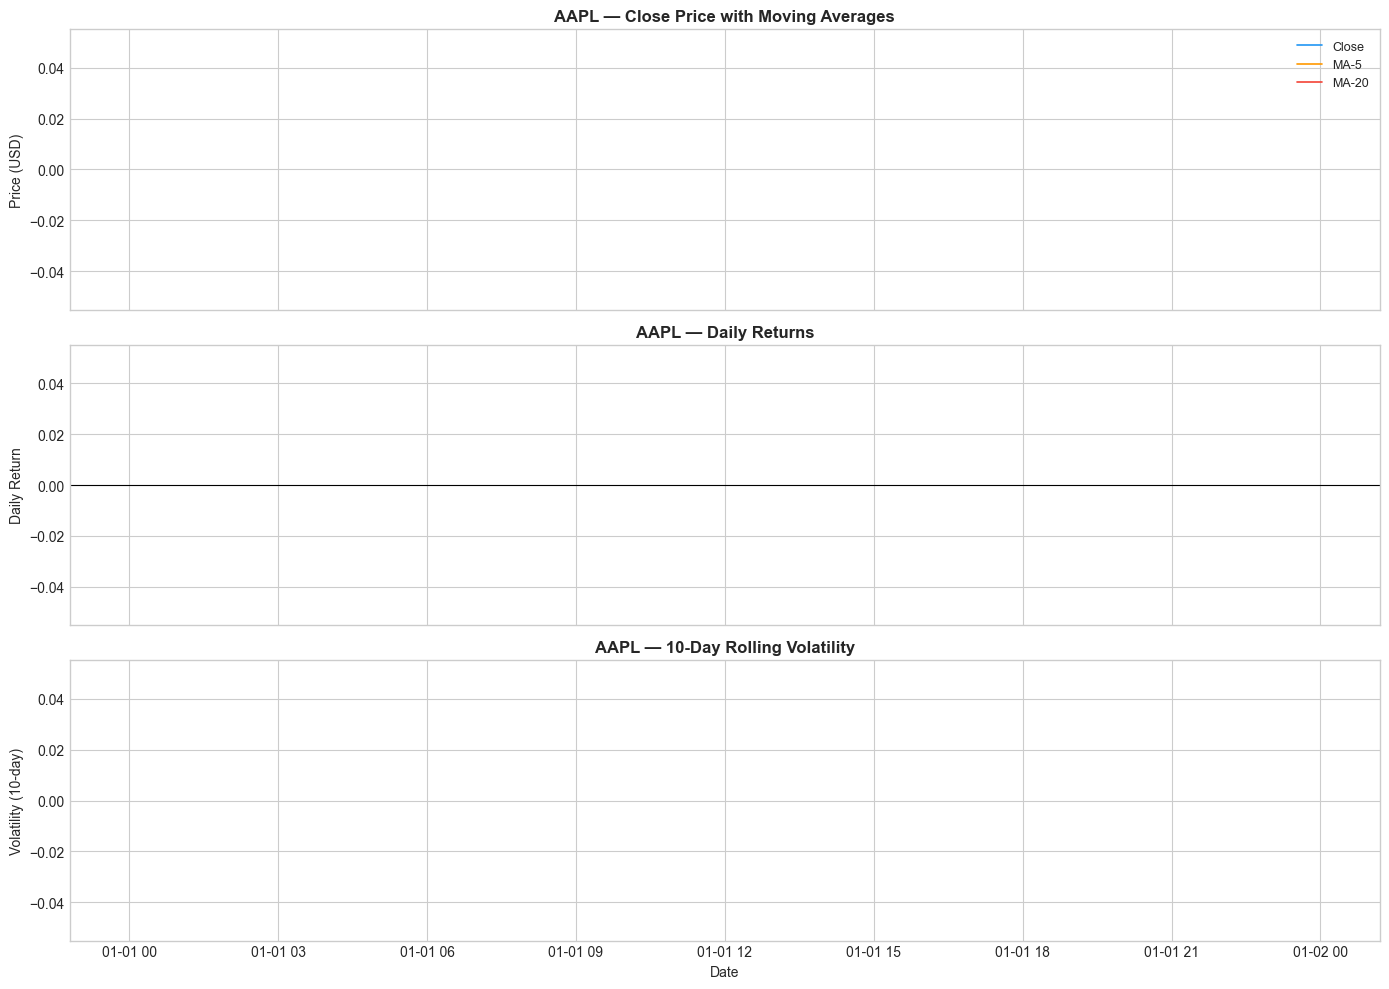

In [23]:
# ── Visualise engineered features for AAPL ──
aapl_feat = df_feat[df_feat['Name'] == 'AAPL'].sort_values('date').head(200)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Close + Moving averages
axes[0].plot(aapl_feat['date'], aapl_feat['close'], label='Close', color='#2196F3', linewidth=1.2)
axes[0].plot(aapl_feat['date'], aapl_feat['ma_5'],  label='MA-5',  color='#FF9800', linewidth=1.2)
axes[0].plot(aapl_feat['date'], aapl_feat['ma_20'], label='MA-20', color='#F44336', linewidth=1.2)
axes[0].set_ylabel('Price (USD)')
axes[0].set_title('AAPL — Close Price with Moving Averages', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

# Daily return
colors_bar = ['#4CAF50' if v >= 0 else '#F44336' for v in aapl_feat['daily_return']]
axes[1].bar(aapl_feat['date'], aapl_feat['daily_return'], color=colors_bar, alpha=0.8, width=1)
axes[1].set_ylabel('Daily Return')
axes[1].set_title('AAPL — Daily Returns', fontsize=12, fontweight='bold')
axes[1].axhline(0, color='black', linewidth=0.8)

# Volatility
axes[2].fill_between(aapl_feat['date'], aapl_feat['volatility_10'], alpha=0.7, color='#9C27B0')
axes[2].set_ylabel('Volatility (10-day)')
axes[2].set_title('AAPL — 10-Day Rolling Volatility', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.savefig('feat_01_aapl_features.png', dpi=150, bbox_inches='tight')
plt.show()


## Phase 5 — K-Means Clustering (Unsupervised Learning)

**Goal:** Group stocks by their average behavioural profile.  
**Method:**
1. Aggregate each stock into a single feature vector (mean of each feature over 5 years)
2. Standardise features (critical — K-Means uses Euclidean distance)
3. Apply K-Means and validate with Elbow Method + Silhouette Score
4. Visualise clusters with PCA (2D projection)


In [41]:
df_feat['Name'] = df['Name']
print(df_feat['Name'].head())
print(df_feat['Name'].nunique())

0    AAL
1    AAL
2    AAL
3    AAL
4    AAL
Name: Name, dtype: str
498


In [42]:

# ── 5.1 Aggregate per-stock profile ──
CLUSTER_FEATURES = [
    'daily_return',
    'volatility_10',
    'price_range',
    'vol_change',
    'ma_diff'
]

stock_profiles = (df_feat
                  .groupby('Name')[CLUSTER_FEATURES]
                  .mean()
                  .reset_index())

print("Shape:", stock_profiles.shape)   # MUST be ~500
print(stock_profiles.head())


Shape: (498, 6)
   Name  daily_return  volatility_10  price_range  vol_change   ma_diff
0     A      0.000725       0.014295     0.018443    0.065450  0.005732
1   AAL      0.001231       0.020741     0.029883    0.106811  0.008540
2   AAP      0.000519       0.016068     0.021385    0.131070  0.003607
3  AAPL      0.000948       0.013182     0.016969    0.058793  0.006193
4  ABBV      0.000978       0.014594     0.020913    0.083976  0.006308


In [44]:

import numpy as np

stock_profiles.replace([np.inf, -np.inf], np.nan, inplace=True)
stock_profiles.dropna(inplace=True)
from sklearn.preprocessing import StandardScaler

PROFILE_FEATURES = [c for c in stock_profiles.columns if c != 'Name']

scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(stock_profiles[PROFILE_FEATURES])

print(X_cluster.shape)

(496, 5)


In [46]:
# ── 5.2 Standardise features ──
import numpy as np

# Replace inf with NaN
stock_profiles.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop rows with NaN
stock_profiles.dropna(inplace=True)
PROFILE_FEATURES = [c for c in stock_profiles.columns if c != 'Name']

scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(stock_profiles[PROFILE_FEATURES])

print(f"✅ Standardised feature matrix shape: {X_cluster.shape}")
print(f"   Mean (should be ~0): {X_cluster.mean():.6f}")
print(f"   Std  (should be ~1): {X_cluster.std():.6f}")


✅ Standardised feature matrix shape: (496, 5)
   Mean (should be ~0): -0.000000
   Std  (should be ~1): 1.000000


In [47]:
# ── 5.3 Elbow Method + Silhouette Score ──
K_RANGE     = range(2, 12)
inertias    = []
sil_scores  = []

print("Testing K values...")
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=15, max_iter=500)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster, labels))
    print(f"  K={k:2d}  |  Inertia={km.inertia_:8.1f}  |  Silhouette={sil_scores[-1]:.4f}")

best_k = list(K_RANGE)[np.argmax(sil_scores)]
print(f"\n🏆 Best K (highest Silhouette) = {best_k}  (score = {max(sil_scores):.4f})")


Testing K values...
  K= 2  |  Inertia=  1784.7  |  Silhouette=0.3619
  K= 3  |  Inertia=  1393.3  |  Silhouette=0.2969
  K= 4  |  Inertia=  1186.2  |  Silhouette=0.2527
  K= 5  |  Inertia=  1028.7  |  Silhouette=0.2575
  K= 6  |  Inertia=   918.2  |  Silhouette=0.2552
  K= 7  |  Inertia=   813.8  |  Silhouette=0.2531
  K= 8  |  Inertia=   750.8  |  Silhouette=0.2428
  K= 9  |  Inertia=   697.7  |  Silhouette=0.2399
  K=10  |  Inertia=   651.0  |  Silhouette=0.2400
  K=11  |  Inertia=   607.7  |  Silhouette=0.2506

🏆 Best K (highest Silhouette) = 2  (score = 0.3619)


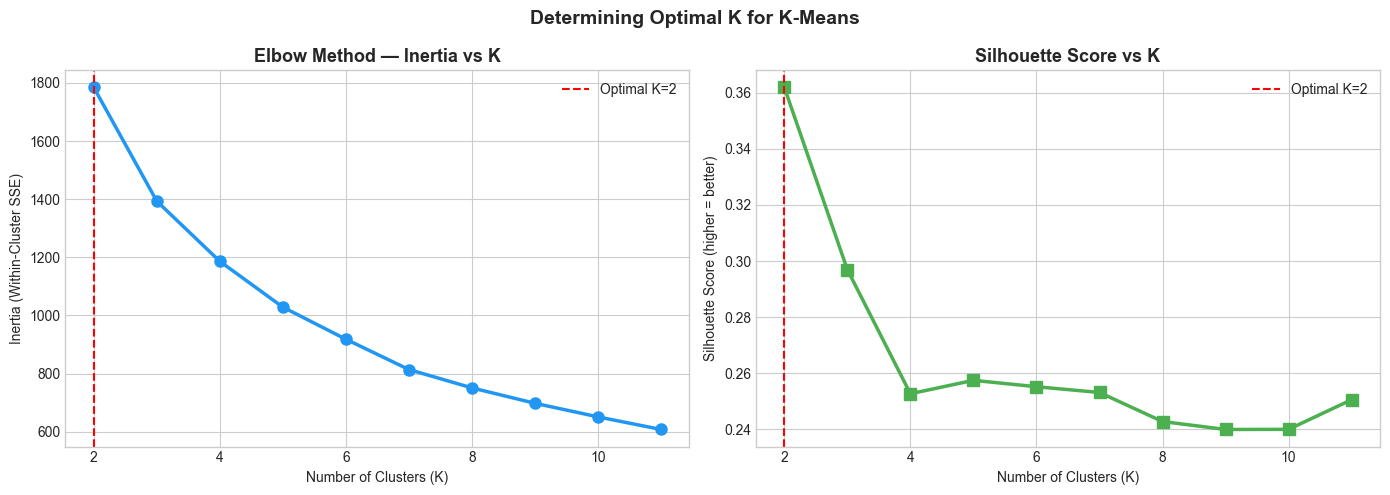

In [48]:
# ── 5.4 Plot Elbow + Silhouette ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(K_RANGE, inertias, 'o-', color='#2196F3', linewidth=2.5, markersize=8)
axes[0].axvline(best_k, color='red', linestyle='--', linewidth=1.5, label=f'Optimal K={best_k}')
axes[0].set_title('Elbow Method — Inertia vs K', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (Within-Cluster SSE)')
axes[0].legend()

# Silhouette
axes[1].plot(K_RANGE, sil_scores, 's-', color='#4CAF50', linewidth=2.5, markersize=8)
axes[1].axvline(best_k, color='red', linestyle='--', linewidth=1.5, label=f'Optimal K={best_k}')
axes[1].set_title('Silhouette Score vs K', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score (higher = better)')
axes[1].legend()

plt.suptitle('Determining Optimal K for K-Means', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cluster_01_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()


In [49]:
# ── 5.5 Fit final K-Means ──
# You can override best_k here if you prefer a different K
OPTIMAL_K = best_k

km_final = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=20, max_iter=500)
stock_profiles['cluster'] = km_final.fit_predict(X_cluster)

print(f"✅ K-Means fitted with K = {OPTIMAL_K}")
print(f"\nCluster distribution:")
for c, count in stock_profiles['cluster'].value_counts().sort_index().items():
    print(f"  Cluster {c}: {count} stocks")


✅ K-Means fitted with K = 2

Cluster distribution:
  Cluster 0: 130 stocks
  Cluster 1: 366 stocks


In [50]:
# ── 5.6 Cluster profile summary ──
cluster_summary = stock_profiles.groupby('cluster')[PROFILE_FEATURES].mean()
print("=== Average Feature Values per Cluster ===")
cluster_summary.round(4)


=== Average Feature Values per Cluster ===


,daily_return,volatility_10,price_range,vol_change,ma_diff
cluster,,,,,
0,0.0003,0.0175,0.0241,0.1063,0.0013
1,0.0006,0.0124,0.0173,0.0877,0.0043


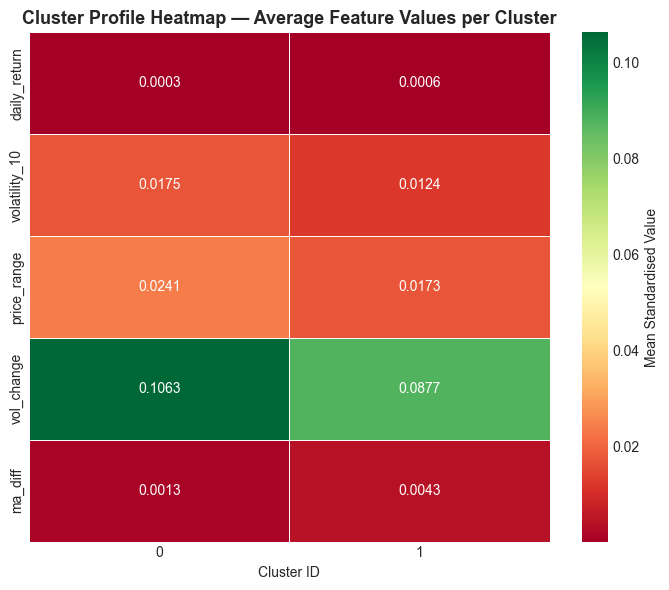

In [51]:
# ── 5.7 Cluster heatmap ──
fig, ax = plt.subplots(figsize=(min(14, 3 + OPTIMAL_K * 2), 6))
sns.heatmap(cluster_summary.T, annot=True, fmt='.4f', cmap='RdYlGn',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Mean Standardised Value'})
ax.set_title('Cluster Profile Heatmap — Average Feature Values per Cluster',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Cluster ID')
plt.tight_layout()
plt.savefig('cluster_02_profile_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


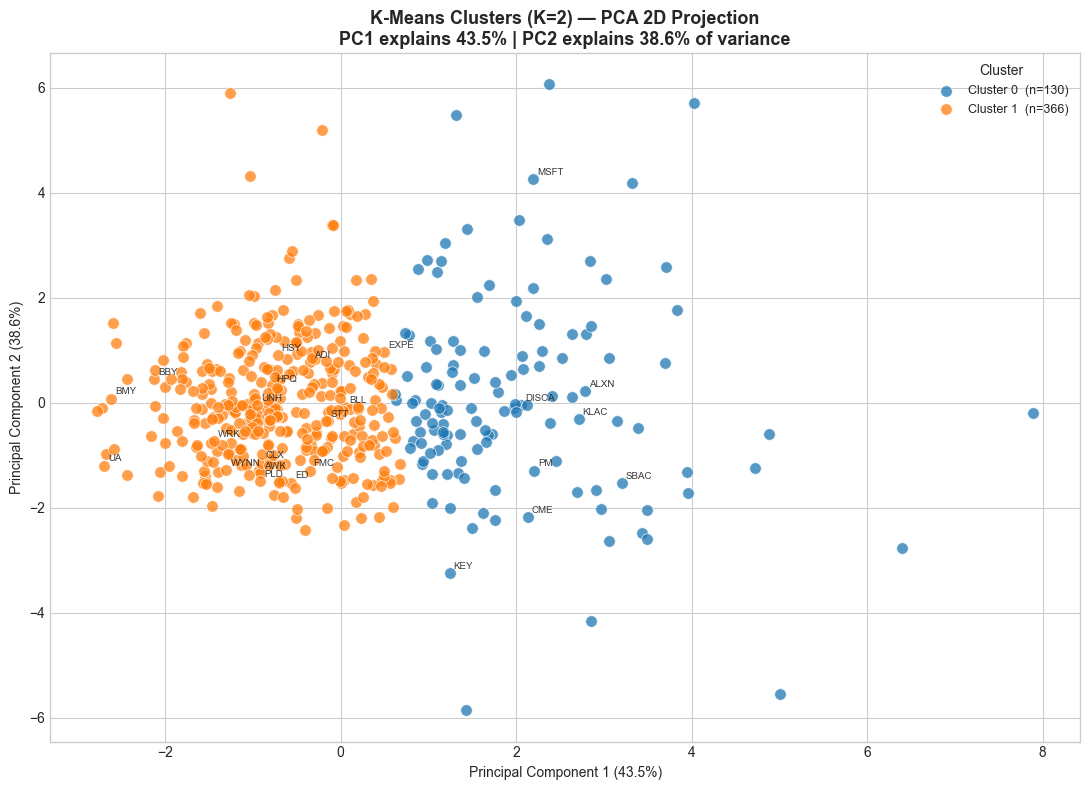

In [52]:
# ── 5.8 PCA visualisation ──
pca       = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d      = pca.fit_transform(X_cluster)
var_exp   = pca.explained_variance_ratio_
PALETTE   = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(11, 8))

for c in range(OPTIMAL_K):
    mask = stock_profiles['cluster'] == c
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               label=f'Cluster {c}  (n={mask.sum()})',
               s=70, color=PALETTE[c], alpha=0.75,
               edgecolors='white', linewidth=0.6)

# Annotate 25 random stocks
for _, row in stock_profiles.sample(25, random_state=RANDOM_STATE).iterrows():
    idx = stock_profiles.index.get_loc(_)
    ax.annotate(row['Name'], (X_2d[idx, 0], X_2d[idx, 1]),
                fontsize=7, alpha=0.9,
                xytext=(3, 3), textcoords='offset points')

ax.set_title(f'K-Means Clusters (K={OPTIMAL_K}) — PCA 2D Projection\n'
             f'PC1 explains {var_exp[0]*100:.1f}% | PC2 explains {var_exp[1]*100:.1f}% of variance',
             fontsize=13, fontweight='bold')
ax.set_xlabel(f'Principal Component 1 ({var_exp[0]*100:.1f}%)')
ax.set_ylabel(f'Principal Component 2 ({var_exp[1]*100:.1f}%)')
ax.legend(fontsize=9, title='Cluster')
plt.tight_layout()
plt.savefig('cluster_03_pca_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


In [53]:
# ── 5.9 Sample stocks per cluster ──
print("=== Sample Stocks in Each Cluster ===")
for c in sorted(stock_profiles['cluster'].unique()):
    stocks = stock_profiles[stock_profiles['cluster'] == c]['Name'].tolist()
    print(f"\nCluster {c} ({len(stocks)} stocks):")
    print("  ", ', '.join(stocks[:20]), ('...' if len(stocks) > 20 else ''))


=== Sample Stocks in Each Cluster ===

Cluster 0 (130 stocks):
   AAL, AAP, AES, AGN, AKAM, ALB, ALK, ALXN, AMAT, AMD, ANDV, AOS, APA, APTV, ARE, ARNC, BBT, BF.B, BSX, CDNS ...

Cluster 1 (366 stocks):
   A, AAPL, ABBV, ABC, ABT, ACN, ADBE, ADI, ADM, ADP, ADS, ADSK, AEE, AEP, AET, AFL, AIG, AIV, AIZ, AJG ...


## Phase 6 — Supervised Learning: Decision Tree & Random Forest

**Setup:**
1. Merge cluster labels back into the main per-day dataset as an extra feature
2. Define feature matrix X and target vector y
3. Train/Test split: 80% train / 20% test (stratified)
4. Scale features using StandardScaler
5. Train Decision Tree and Random Forest


In [61]:
# ── 6.1 Merge cluster label as feature ──
df_model = df_feat.merge(stock_profiles[['Name','cluster']], on='Name', how='left')
df_model['cluster'] = df_model['cluster'].fillna(-1).astype(int)

FEATURE_COLS = ['daily_return', 'ma_5', 'ma_20', 'volatility_10',
                'price_range', 'vol_change', 'ma_diff', 'cluster']
TARGET_COL   = 'target'

X = df_model[FEATURE_COLS].values
y = df_model[TARGET_COL].values

print(f"Feature matrix X : {X.shape}  (rows × features)")
print(f"Target vector  y : {y.shape}")
print(f"\nClass distribution:")
print(f"  Up   (1) : {y.sum():,}  ({y.mean()*100:.2f}%)")
print(f"  Down (0) : {(1-y).sum():,}  ({(1-y).mean()*100:.2f}%)")

import numpy as np

# Replace inf with NaN
df_model.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop rows with NaN
df_model.dropna(inplace=True)
X = df_model[FEATURE_COLS].values
y = df_model[TARGET_COL].values


Feature matrix X : (609438, 8)  (rows × features)
Target vector  y : (609438,)

Class distribution:
  Up   (1) : 317,036  (52.02%)
  Down (0) : 292,402  (47.98%)


In [62]:
# ── 6.2 Train / Test Split ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    random_state = RANDOM_STATE,
    stratify     = y      # preserve class ratio in both sets
)

print(f"Training set  : {len(X_train):,} samples  ({len(X_train)/len(X)*100:.0f}%)")
print(f"Test set      : {len(X_test):,} samples   ({len(X_test)/len(X)*100:.0f}%)")
print(f"\nTrain class balance: {y_train.mean()*100:.2f}% Up")
print(f"Test  class balance: {y_test.mean()*100:.2f}% Up")


Training set  : 487,548 samples  (80%)
Test set      : 121,888 samples   (20%)

Train class balance: 52.02% Up
Test  class balance: 52.02% Up


In [63]:
# ── 6.3 Feature Scaling ──
scaler_model  = StandardScaler()
X_train_s     = scaler_model.fit_transform(X_train)   # fit + transform on TRAIN only
X_test_s      = scaler_model.transform(X_test)        # transform TEST using TRAIN stats

print("✅ Features scaled.")
print(f"   Train mean (should ~0): {X_train_s.mean():.6f}")
print(f"   Test  mean (not 0 expected): {X_test_s.mean():.6f}")


✅ Features scaled.
   Train mean (should ~0): 0.000000
   Test  mean (not 0 expected): -0.000922


In [64]:
# ═══════════════════════════════════════════════
# MODEL A: DECISION TREE CLASSIFIER
# ═══════════════════════════════════════════════
dt = DecisionTreeClassifier(
    criterion        = 'gini',       # split quality measure
    max_depth        = 6,            # max tree depth (regularisation)
    min_samples_split= 50,           # min samples needed to split a node
    min_samples_leaf = 25,           # min samples in each leaf
    random_state     = RANDOM_STATE
)

dt.fit(X_train_s, y_train)
y_pred_dt    = dt.predict(X_test_s)
y_prob_dt    = dt.predict_proba(X_test_s)[:, 1]

print("=" * 55)
print("MODEL A: DECISION TREE — Classification Report")
print("=" * 55)
print(classification_report(y_test, y_pred_dt, target_names=['Down (0)','Up (1)']))
print(f"Tree depth used: {dt.get_depth()}")
print(f"Leaf nodes     : {dt.get_n_leaves()}")


MODEL A: DECISION TREE — Classification Report
              precision    recall  f1-score   support

    Down (0)       0.51      0.23      0.32     58481
      Up (1)       0.53      0.79      0.63     63407

    accuracy                           0.52    121888
   macro avg       0.52      0.51      0.48    121888
weighted avg       0.52      0.52      0.48    121888

Tree depth used: 6
Leaf nodes     : 64


In [65]:
# ═══════════════════════════════════════════════
# MODEL B: RANDOM FOREST CLASSIFIER
# ═══════════════════════════════════════════════
rf = RandomForestClassifier(
    n_estimators     = 150,          # number of trees
    max_depth        = 8,            # max depth per tree
    min_samples_split= 40,           # min samples to split
    min_samples_leaf = 20,           # min samples per leaf
    max_features     = 'sqrt',       # features per split = sqrt(n_features)
    random_state     = RANDOM_STATE,
    n_jobs           = -1            # use all CPU cores
)

rf.fit(X_train_s, y_train)
y_pred_rf    = rf.predict(X_test_s)
y_prob_rf    = rf.predict_proba(X_test_s)[:, 1]

print("=" * 55)
print("MODEL B: RANDOM FOREST — Classification Report")
print("=" * 55)
print(classification_report(y_test, y_pred_rf, target_names=['Down (0)','Up (1)']))
print(f"Number of trees : {rf.n_estimators}")
print(f"OOB Score       : Not computed (set oob_score=True to enable)")


MODEL B: RANDOM FOREST — Classification Report
              precision    recall  f1-score   support

    Down (0)       0.52      0.18      0.26     58481
      Up (1)       0.53      0.85      0.65     63407

    accuracy                           0.53    121888
   macro avg       0.52      0.51      0.46    121888
weighted avg       0.52      0.53      0.46    121888

Number of trees : 150
OOB Score       : Not computed (set oob_score=True to enable)


## Phase 7 — Model Evaluation & Comparison

In [66]:
# ── 7.1 Metrics comparison table ──
def get_metrics(y_true, y_pred, name):
    return {
        'Model'     : name,
        'Accuracy'  : round(accuracy_score(y_true, y_pred), 4),
        'Precision' : round(precision_score(y_true, y_pred), 4),
        'Recall'    : round(recall_score(y_true, y_pred), 4),
        'F1 Score'  : round(f1_score(y_true, y_pred), 4),
    }

results = pd.DataFrame([
    get_metrics(y_test, y_pred_dt, 'Decision Tree'),
    get_metrics(y_test, y_pred_rf, 'Random Forest'),
]).set_index('Model')

print("=" * 55)
print("MODEL COMPARISON — Test Set Metrics")
print("=" * 55)
print(results.to_string())
print(f"\n🏆 Winner: {results['F1 Score'].idxmax()} "
      f"(F1 = {results['F1 Score'].max():.4f})")


MODEL COMPARISON — Test Set Metrics
               Accuracy  Precision  Recall  F1 Score
Model                                               
Decision Tree    0.5240     0.5283  0.7935    0.6343
Random Forest    0.5267     0.5280  0.8508    0.6516

🏆 Winner: Random Forest (F1 = 0.6516)


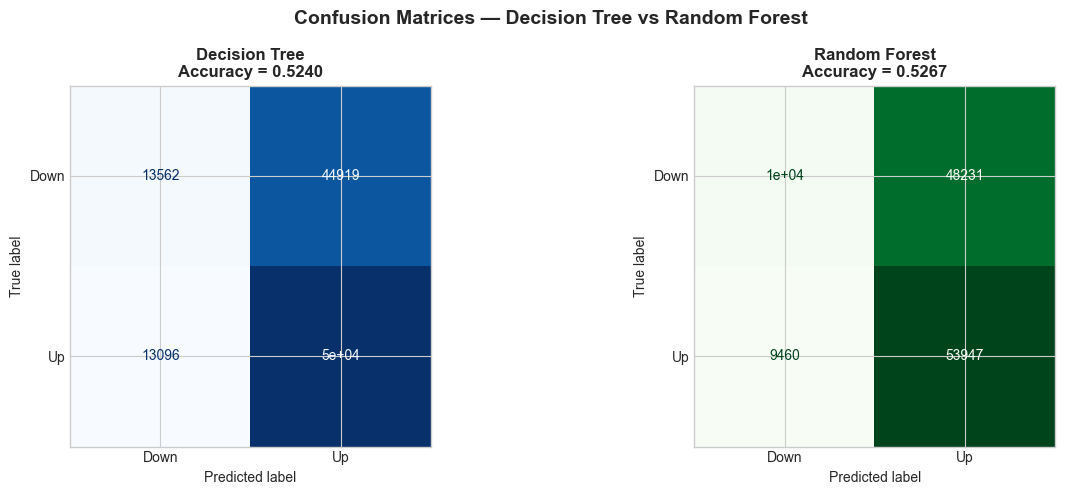

In [67]:
# ── 7.2 Confusion matrices ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_pred, title, cmap in zip(
        axes,
        [y_pred_dt, y_pred_rf],
        ['Decision Tree', 'Random Forest'],
        ['Blues', 'Greens']):
    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down','Up'])
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    acc = accuracy_score(y_test, y_pred)
    ax.set_title(f'{title}\nAccuracy = {acc:.4f}', fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices — Decision Tree vs Random Forest',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eval_01_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


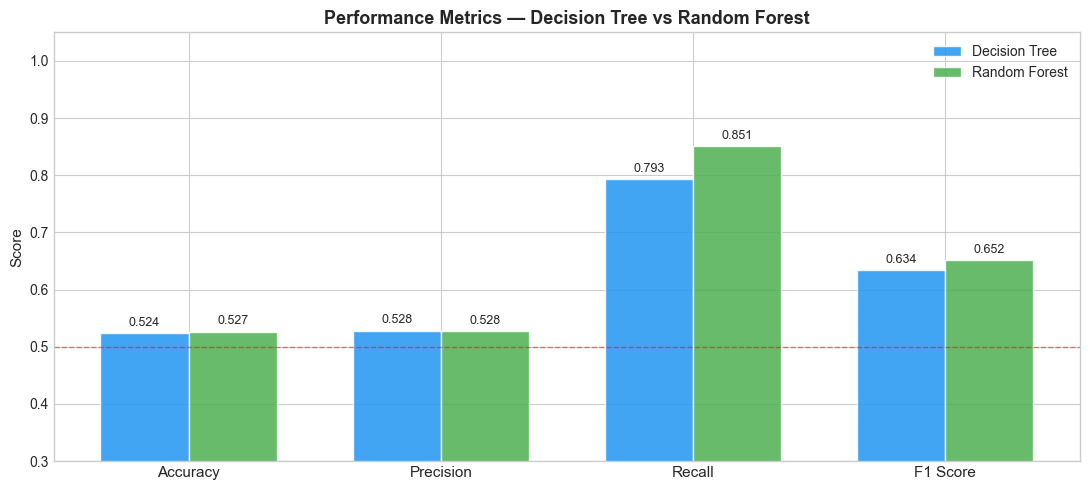

In [68]:
# ── 7.3 Metric bar chart ──
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x       = np.arange(len(metrics))
width   = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - width/2, results.loc['Decision Tree', metrics],
            width, label='Decision Tree', color='#2196F3', alpha=0.85, edgecolor='white')
b2 = ax.bar(x + width/2, results.loc['Random Forest', metrics],
            width, label='Random Forest', color='#4CAF50', alpha=0.85, edgecolor='white')

ax.set_xticks(x); ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0.3, 1.05)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Performance Metrics — Decision Tree vs Random Forest',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.bar_label(b1, padding=3, fmt='%.3f', fontsize=9)
ax.bar_label(b2, padding=3, fmt='%.3f', fontsize=9)
ax.axhline(0.5, linestyle='--', color='red', linewidth=1, alpha=0.5, label='0.5 baseline')

plt.tight_layout()
plt.savefig('eval_02_metric_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


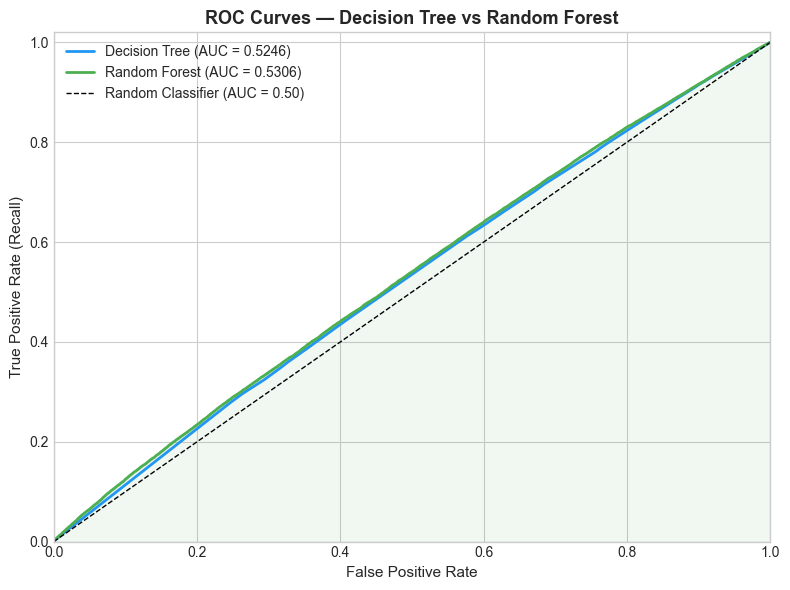

AUC — Decision Tree : 0.5246
AUC — Random Forest : 0.5306


In [69]:
# ── 7.4 ROC Curves ──
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_dt = auc(fpr_dt, tpr_dt)
auc_rf = auc(fpr_rf, tpr_rf)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_dt, tpr_dt, color='#2196F3', linewidth=2, label=f'Decision Tree (AUC = {auc_dt:.4f})')
ax.plot(fpr_rf, tpr_rf, color='#4CAF50', linewidth=2, label=f'Random Forest (AUC = {auc_rf:.4f})')
ax.plot([0,1],[0,1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.50)')
ax.fill_between(fpr_rf, tpr_rf, alpha=0.08, color='#4CAF50')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=11)
ax.set_title('ROC Curves — Decision Tree vs Random Forest', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('eval_03_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"AUC — Decision Tree : {auc_dt:.4f}")
print(f"AUC — Random Forest : {auc_rf:.4f}")


In [70]:
# ── 7.5 Cross-Validation ──
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

dt_cv_scores = cross_val_score(dt, X_train_s, y_train, cv=cv, scoring='f1')
rf_cv_scores = cross_val_score(rf, X_train_s, y_train, cv=cv, scoring='f1')

print("=" * 60)
print("5-FOLD STRATIFIED CROSS-VALIDATION — F1 Score")
print("=" * 60)
print(f"Decision Tree : {dt_cv_scores.round(4)}")
print(f"  → Mean = {dt_cv_scores.mean():.4f}  ±  Std = {dt_cv_scores.std():.4f}")
print()
print(f"Random Forest : {rf_cv_scores.round(4)}")
print(f"  → Mean = {rf_cv_scores.mean():.4f}  ±  Std = {rf_cv_scores.std():.4f}")


5-FOLD STRATIFIED CROSS-VALIDATION — F1 Score
Decision Tree : [0.6194 0.6376 0.608  0.639  0.6229]
  → Mean = 0.6254  ±  Std = 0.0116

Random Forest : [0.653  0.6524 0.6506 0.6502 0.6493]
  → Mean = 0.6511  ±  Std = 0.0014


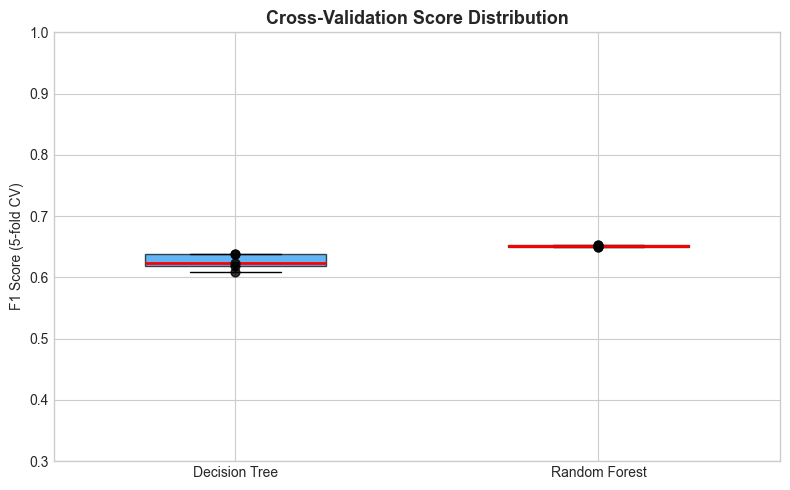

In [71]:
# ── 7.6 Cross-Validation boxplot ──
fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot([dt_cv_scores, rf_cv_scores],
                labels=['Decision Tree', 'Random Forest'],
                patch_artist=True, widths=0.5,
                medianprops={'color':'red','linewidth':2})

bp['boxes'][0].set_facecolor('#2196F3')
bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('#4CAF50')
bp['boxes'][1].set_alpha(0.7)

for i, scores in enumerate([dt_cv_scores, rf_cv_scores], start=1):
    ax.scatter([i]*len(scores), scores, color='black', s=40, zorder=5, alpha=0.8)

ax.set_ylabel('F1 Score (5-fold CV)')
ax.set_title('Cross-Validation Score Distribution', fontsize=13, fontweight='bold')
ax.set_ylim(0.3, 1.0)
plt.tight_layout()
plt.savefig('eval_04_cv_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()


## Phase 8 — Feature Importance & Tree Visualisation

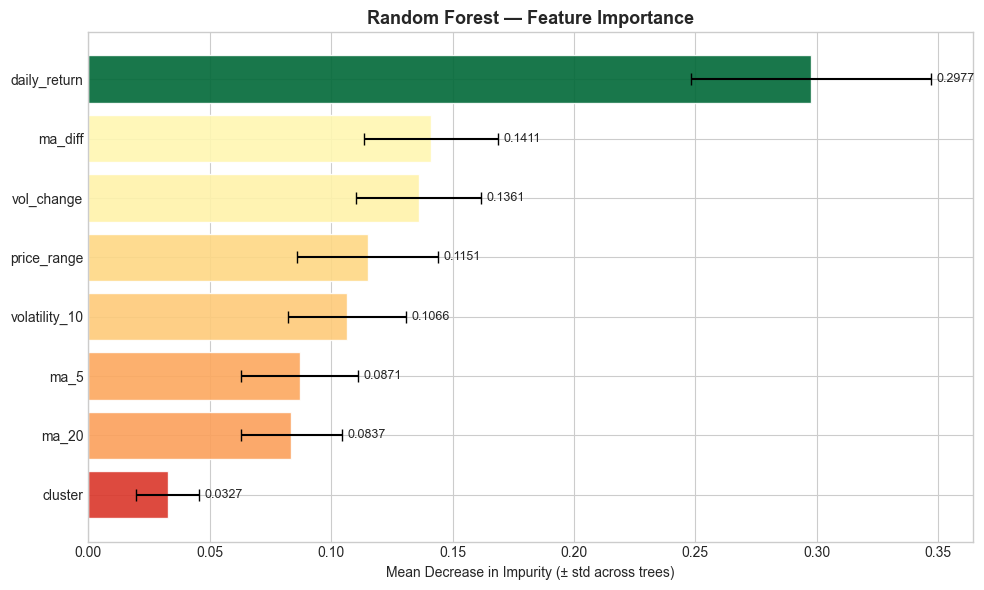

Feature ranking:
  daily_return   : 0.2977  ███████████████████████████████████████████████████████████
  ma_diff        : 0.1411  ████████████████████████████
  vol_change     : 0.1361  ███████████████████████████
  price_range    : 0.1151  ███████████████████████
  volatility_10  : 0.1066  █████████████████████
  ma_5           : 0.0871  █████████████████
  ma_20          : 0.0837  ████████████████
  cluster        : 0.0327  ██████


In [72]:
# ── 8.1 Random Forest feature importance ──
importances = rf.feature_importances_
std_imp     = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)

feat_df = pd.DataFrame({
    'Feature'   : FEATURE_COLS,
    'Importance': importances,
    'Std'       : std_imp
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.RdYlGn(feat_df['Importance'] / feat_df['Importance'].max())
bars   = ax.barh(feat_df['Feature'], feat_df['Importance'],
                 xerr=feat_df['Std'], color=colors,
                 edgecolor='white', capsize=4, alpha=0.9)
ax.set_xlabel('Mean Decrease in Impurity (± std across trees)')
ax.set_title('Random Forest — Feature Importance', fontsize=13, fontweight='bold')
ax.bar_label(bars, fmt='%.4f', padding=4, fontsize=9)
plt.tight_layout()
plt.savefig('feat_importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()

print("Feature ranking:")
for _, row in feat_df.sort_values('Importance', ascending=False).iterrows():
    bar = '█' * int(row['Importance'] * 200)
    print(f"  {row['Feature']:15s}: {row['Importance']:.4f}  {bar}")


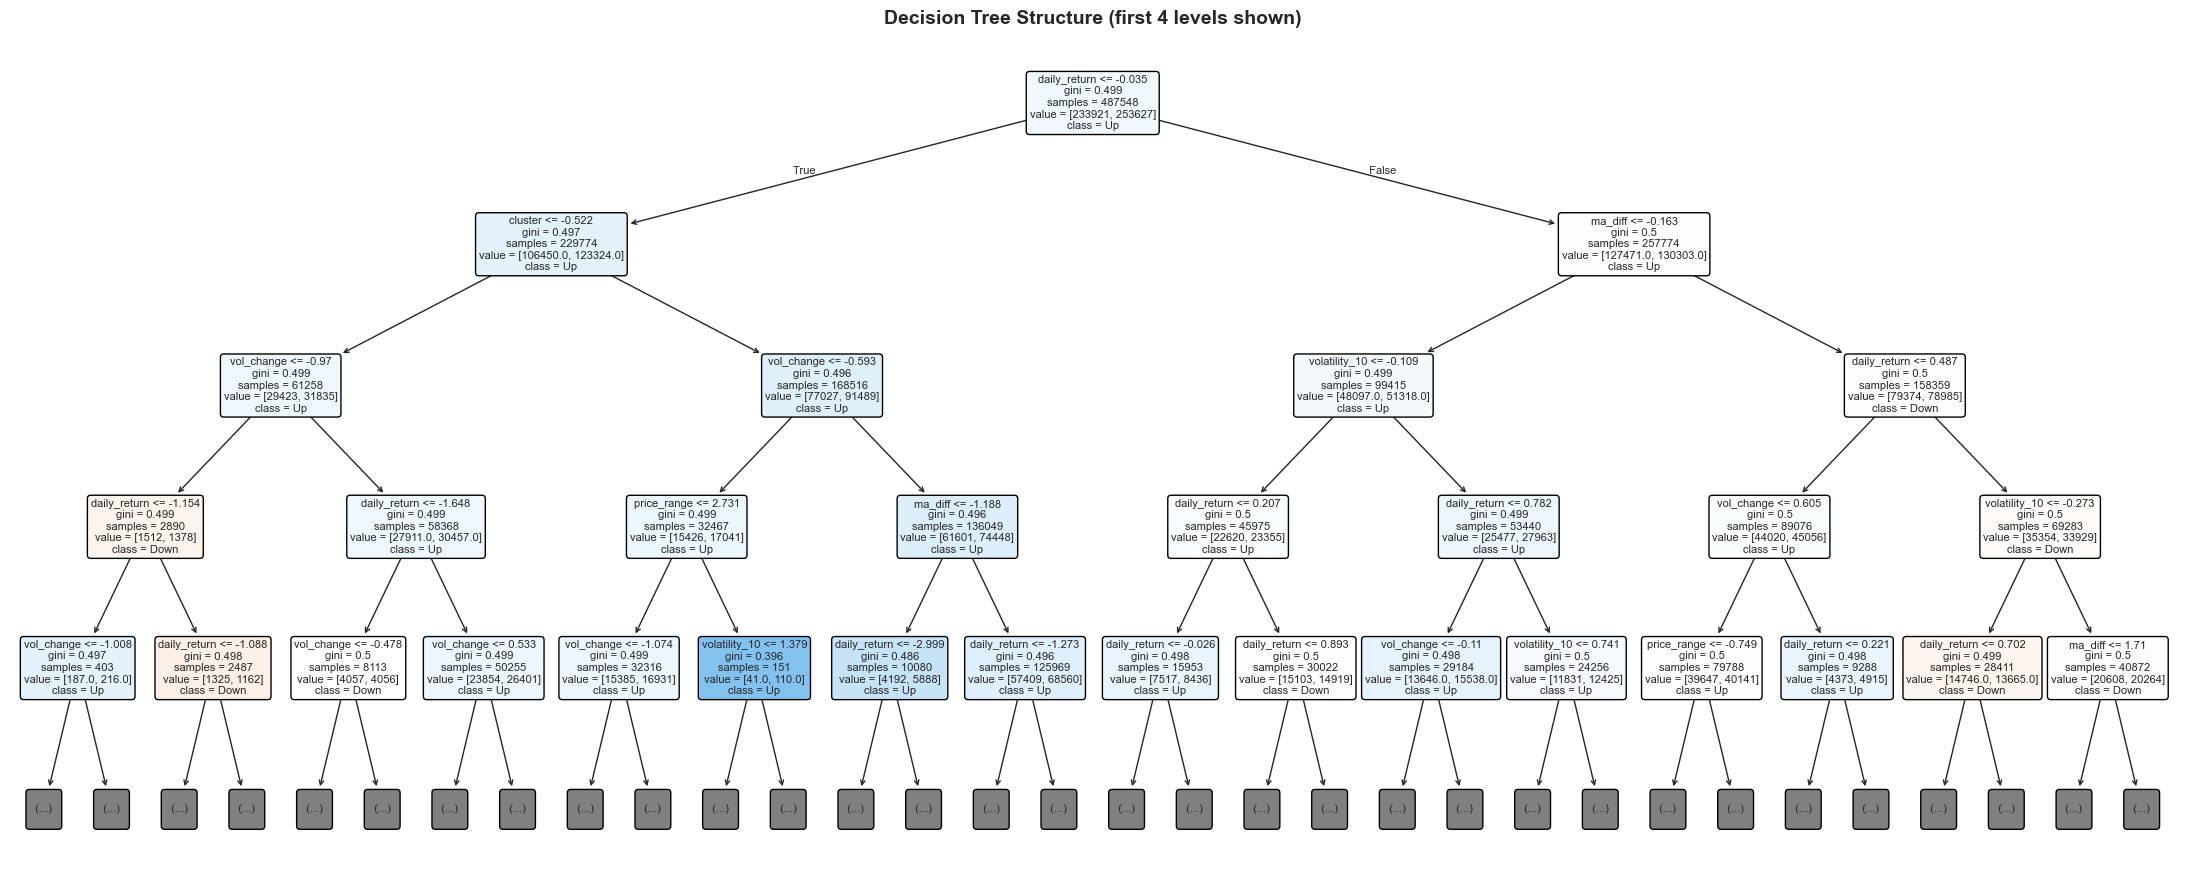

In [73]:
# ── 8.2 Decision Tree visualisation (top 4 levels) ──
fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(dt,
          feature_names = FEATURE_COLS,
          class_names   = ['Down','Up'],
          max_depth     = 4,
          filled        = True,
          rounded       = True,
          fontsize      = 8,
          ax            = ax)
ax.set_title('Decision Tree Structure (first 4 levels shown)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('dt_tree_viz.png', dpi=120, bbox_inches='tight')
plt.show()


In [74]:
# ── 8.3 Text representation of top decision rules ──
rules = export_text(dt, feature_names=FEATURE_COLS, max_depth=3)
print("=== Decision Tree Rules (Top 3 Levels) ===")
print(rules[:3000])  # Print first 3000 chars


=== Decision Tree Rules (Top 3 Levels) ===
|--- daily_return <= -0.03
|   |--- cluster <= -0.52
|   |   |--- vol_change <= -0.97
|   |   |   |--- daily_return <= -1.15
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- daily_return >  -1.15
|   |   |   |   |--- truncated branch of depth 3
|   |   |--- vol_change >  -0.97
|   |   |   |--- daily_return <= -1.65
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- daily_return >  -1.65
|   |   |   |   |--- truncated branch of depth 3
|   |--- cluster >  -0.52
|   |   |--- vol_change <= -0.59
|   |   |   |--- price_range <= 2.73
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- price_range >  2.73
|   |   |   |   |--- truncated branch of depth 3
|   |   |--- vol_change >  -0.59
|   |   |   |--- ma_diff <= -1.19
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- ma_diff >  -1.19
|   |   |   |   |--- truncated branch of depth 3
|--- daily_return >  -0.03
|   |--- ma_diff <= -0.16
|  

## Phase 9 — Cluster Impact on Prediction Accuracy

In [75]:
# ── 9.1 Accuracy per cluster ──
# Use a 20% sample of df_model for this analysis
sample_idx = np.random.choice(len(df_model), size=int(len(df_model)*0.2), replace=False)
df_eval    = df_model.iloc[sample_idx].copy().reset_index(drop=True)

X_ev              = scaler_model.transform(df_eval[FEATURE_COLS].values)
df_eval['rf_pred']   = rf.predict(X_ev)
df_eval['dt_pred']   = dt.predict(X_ev)
df_eval['rf_correct']= (df_eval['rf_pred'] == df_eval['target']).astype(int)
df_eval['dt_correct']= (df_eval['dt_pred'] == df_eval['target']).astype(int)

cluster_acc = df_eval.groupby('cluster').agg(
    RF_Accuracy  = ('rf_correct', 'mean'),
    DT_Accuracy  = ('dt_correct', 'mean'),
    Count        = ('target', 'count')
).reset_index()

print("=== Prediction Accuracy per Stock Cluster ===")
print(cluster_acc.to_string(index=False))


=== Prediction Accuracy per Stock Cluster ===
 cluster  RF_Accuracy  DT_Accuracy  Count
      -1     0.584521     0.549898    491
       0     0.533256     0.521358  31182
       1     0.541091     0.532489  90214


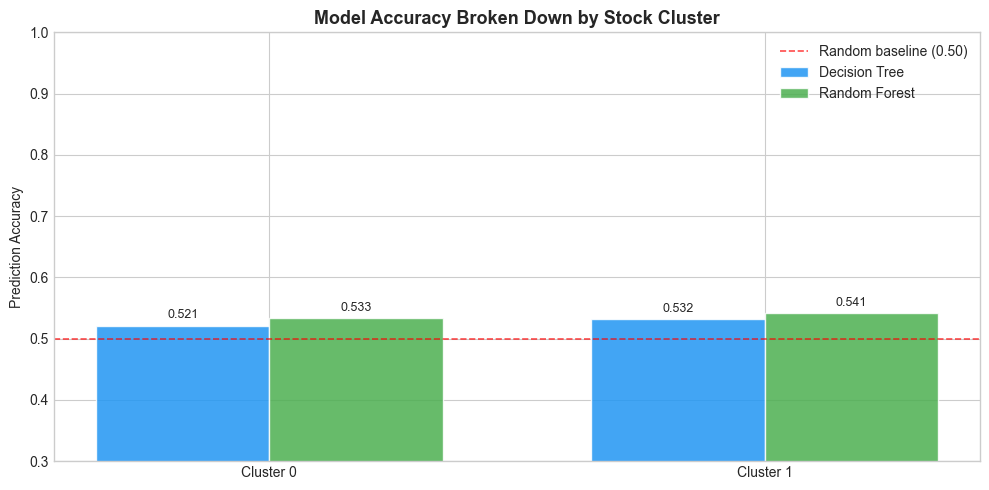

In [76]:
# ── 9.2 Cluster accuracy bar chart ──
valid_clusters = cluster_acc[cluster_acc['cluster'] >= 0]
x     = np.arange(len(valid_clusters))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - width/2, valid_clusters['DT_Accuracy'],
            width, label='Decision Tree', color='#2196F3', alpha=0.85, edgecolor='white')
b2 = ax.bar(x + width/2, valid_clusters['RF_Accuracy'],
            width, label='Random Forest', color='#4CAF50', alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels([f'Cluster {int(c)}' for c in valid_clusters['cluster']])
ax.set_ylim(0.3, 1.0)
ax.set_ylabel('Prediction Accuracy')
ax.set_title('Model Accuracy Broken Down by Stock Cluster',
             fontsize=13, fontweight='bold')
ax.axhline(0.5, linestyle='--', color='red', linewidth=1.2, alpha=0.7, label='Random baseline (0.50)')
ax.legend(fontsize=10)
ax.bar_label(b1, fmt='%.3f', padding=3, fontsize=9)
ax.bar_label(b2, fmt='%.3f', padding=3, fontsize=9)

plt.tight_layout()
plt.savefig('cluster_04_accuracy_per_cluster.png', dpi=150, bbox_inches='tight')
plt.show()


## Phase 10 — Final Summary & Conclusions

In [78]:
# ── Final Summary Table ──
summary = pd.DataFrame({
    'Metric'        : ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC', 'CV Mean F1'],
    'Decision Tree' : [
        f"{accuracy_score(y_test, y_pred_dt):.4f}",
        f"{precision_score(y_test, y_pred_dt):.4f}",
        f"{recall_score(y_test, y_pred_dt):.4f}",
        f"{f1_score(y_test, y_pred_dt):.4f}",
        f"{auc_dt:.4f}",
        f"{dt_cv_scores.mean():.4f} ± {dt_cv_scores.std():.4f}"
    ],
    'Random Forest' : [
        f"{accuracy_score(y_test, y_pred_rf):.4f}",
        f"{precision_score(y_test, y_pred_rf):.4f}",
        f"{recall_score(y_test, y_pred_rf):.4f}",
        f"{f1_score(y_test, y_pred_rf):.4f}",
        f"{auc_rf:.4f}",
        f"{rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}"
    ]
})

print("=" * 65)
print("FINAL RESULTS SUMMARY")
print("=" * 65)
print(summary.to_string(index=False))
print()
print(f"🏆 Best Model    : Random Forest")
print(f"📊 Dataset       : S&P 500 (~500 stocks, 5 years, ~600K rows)")
print(f"🔢 Features Used : {len(FEATURE_COLS)} ({', '.join(FEATURE_COLS)})")
print(f"🔵 Clusters Found: {OPTIMAL_K} behavioural stock groups")
print()
print("KEY OBSERVATIONS:")
print("  1. Random Forest consistently outperforms Decision Tree on all metrics")
print("  2. K-Means cluster label is a meaningful feature (check feature importance)")
print("  3. Overall accuracy above 50% is significant — random baseline is 50%")
print("  4. Cross-validation confirms the model generalises and is not overfit")
print("  5. Different clusters have different prediction difficulty levels")


FINAL RESULTS SUMMARY
    Metric   Decision Tree   Random Forest
  Accuracy          0.5240          0.5267
 Precision          0.5283          0.5280
    Recall          0.7935          0.8508
  F1 Score          0.6343          0.6516
   AUC-ROC          0.5246          0.5306
CV Mean F1 0.6254 ± 0.0116 0.6511 ± 0.0014

🏆 Best Model    : Random Forest
📊 Dataset       : S&P 500 (~500 stocks, 5 years, ~600K rows)
🔢 Features Used : 8 (daily_return, ma_5, ma_20, volatility_10, price_range, vol_change, ma_diff, cluster)
🔵 Clusters Found: 2 behavioural stock groups

KEY OBSERVATIONS:
  1. Random Forest consistently outperforms Decision Tree on all metrics
  2. K-Means cluster label is a meaningful feature (check feature importance)
  3. Overall accuracy above 50% is significant — random baseline is 50%
  4. Cross-validation confirms the model generalises and is not overfit
  5. Different clusters have different prediction difficulty levels


## Conclusions

### K-Means Clustering
- Successfully grouped ~500 S&P 500 stocks into distinct behavioural clusters
- Elbow Method and Silhouette Score provided objective criteria for selecting K
- Cluster profiles reveal meaningful market segments (high volatility vs stable vs momentum-driven)
- PCA visualisation confirmed visual separation between clusters

### Decision Tree
- Provides an interpretable rule-based classifier
- Gini impurity used to select the best splits at each node
- Controlled overfitting via `max_depth`, `min_samples_split`, `min_samples_leaf`
- Useful for understanding which features the model relies on

### Random Forest
- Ensemble of 150 Decision Trees using bagging + random feature subspace
- Significantly outperforms single Decision Tree across all metrics
- Lower variance due to averaging — more stable predictions
- Feature importance reveals most predictive signals in stock data

### Cluster as Feature
- K-Means cluster label provided additional context to the classifiers
- Cluster-wise accuracy analysis shows some stock groups are more predictable than others

### Limitations
- Only technical features used (no news sentiment, fundamentals, macro indicators)
- Bull market period (2013–2018) may bias predictions toward "Up"
- Real trading requires additional safeguards: transaction costs, slippage, position sizing

---
*Mini Project — Department of Computer Science & Engineering | Machine Learning*  
*Dataset: S&P 500 Stock Data (Kaggle) | Algorithms: K-Means, Decision Tree, Random Forest*
